# Probability of Fire (PoF) — Plotting

**Master:** Physics of Data \
**Course:** Laboratory of Computational Physics (LCP), Module B \
**Authors:** Gabriela Landinez Rangel, Andres Rojas Lozano, Fatemeh Dashti, Arash Taraz Jamshidi

*This notebook was created by us to present the final project for LCP MOD B, However it is based on public available code from the Probability of Fire project by ECMWF: https://ecmwf.github.io/AI-Probability-of-Fire/plotting/. With this work, we aim to provide a clear, but friendly, guide with straightforward instructions and detailed explanations for students who, like us, want to reproduce this framework.*

# Probability of Fire Plotter 
This notebook is the final visualization step of the PoF workflow. It opens the forecast file created by `pof3.ipynb`, selects a geographic region, chooses one day, and plots the predicted Probability of Fire on a map.

# Libraries
The code below imports the libraries needed for numerical work, NetCDF files, and geographic plotting.

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import xarray as xr
import matplotlib as mpl
from cartopy import config
import cartopy.crs as ccrs
import cartopy as cart
import sys
import datetime
from matplotlib.colors import ListedColormap,LinearSegmentedColormap


# Open the forecast NetCDF file
This block chooses the forecast year and month, then opens the Probability of Fire forecast file created by `pof3.ipynb`.

The file has the structure:

```text
fire_probability(time, latitude, longitude)
```

That means it contains a stack of maps: one probability map for each day. The longitude coordinates are adjusted and sorted so the map can be plotted correctly.

In [4]:
year=2019
month=12


fire= xr.open_dataset(f"./outputs/POF_prediction_{year}_{month:02d}.nc")
'''
If longitude is negative, convert it to positive 0–360 format.
If longitude is already positive, keep it valid.
'''
fire = fire.assign_coords(longitude=((fire.longitude + 360) % 360)).sortby('longitude')

#convert the xarray object into a normal NumPy array

lats = fire.latitude.values
lons = fire.longitude.values
fire

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 31, latitude: 1801, longitude: 3600)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * longitude         (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
Data variables:
    fire_probability  (time, latitude, longitude) float64 2GB ...

# Select the geographic region

This block cuts the global forecast map down to a smaller region. Here, the latitude and longitude limits select Australia.

Instead of plotting the whole world, the notebook keeps only:

```text
latitude:  -45 to -10
longitude: 110 to 155
```

The result, `sub_ds`, is still an xarray dataset, but only for the selected region.

In [5]:
lat1 = -10
lat2 = -45
lon1 = 110
lon2 = 155

sub_ds = fire.sel(
    latitude=slice(lat1, lat2), 
    longitude=slice(lon1, lon2)
)

sub_ds


<xarray.Dataset> Size: 39MB
Dimensions:           (time: 31, latitude: 350, longitude: 451)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 3kB -10.0 -10.1 -10.2 ... -44.8 -44.9
  * longitude         (longitude) float64 4kB 110.0 110.1 110.2 ... 154.9 155.0
Data variables:
    fire_probability  (time, latitude, longitude) float64 39MB ...

# Define the colour scale

This block creates a custom colour map for the fire-probability classes.

The colours are arranged from low risk to extreme risk:

```text
dark grey/yellow/orange/red/black
```

This colour map will be used later when drawing the Probability of Fire map.

In [6]:
cols = ['#4a5a60','#edcc00','#edcc00','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e21819','#e21819','#e21819','#e21819','#e21819','#000000','#000000']
test = ListedColormap(cols)

# Choose the day and prepare the map values

This block chooses which day to plot.

`index = 0` means the first day in the forecast file, which is 1 December 2019 in this example.

The code then extracts the Probability of Fire values for that day and stores them in `fires`. Very high values are capped at `0.006` so the colour scale remains readable. The `levels` array defines the probability intervals used by the filled contour plot.

In [7]:
index=0# Which index to plot (1st of the month)

#Take the Probability of Fire map for one selected day and store it as a numerical array called fires.

fires = sub_ds.fire_probability[index].values
plot_title = f"Probability of Fire Forecast for {sub_ds.time.values[index].strftime('%d %B %Y') }" #formats the date nicely.

# clipping:  It is used for visualization. Without clipping, a few very high values can dominate the color scale, making the rest of the map hard to see.

fires[fires>0.006]=0.006 # cap high probabilities for visualization

levels = np.arange(16)/2500  # probability contour levels from 0 to 0.006

print(np.shape(fires))
#print(np.nanmax(fire.fire_probability.values))
#print(np.nanmin(fire.fire_probability.values))
#print(np.nanmean(fire.fire_probability.values))

(350, 451)


# Plot the Probability of Fire map

This block creates the final geographic map.

It uses Cartopy to draw Australia with coastlines, borders, ocean, and lakes. The `contourf` function fills the selected region using the Probability of Fire values from `fires`.

The colour bar labels the probability classes as:

```text
Low, Medium, High, Very High, Extreme
```

Finally, the plot is saved as:

```text
outputs/My_PoF_Plot.png
```

C:\Users\sisto\anaconda3\Anaconda_new\envs\pof-fire\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


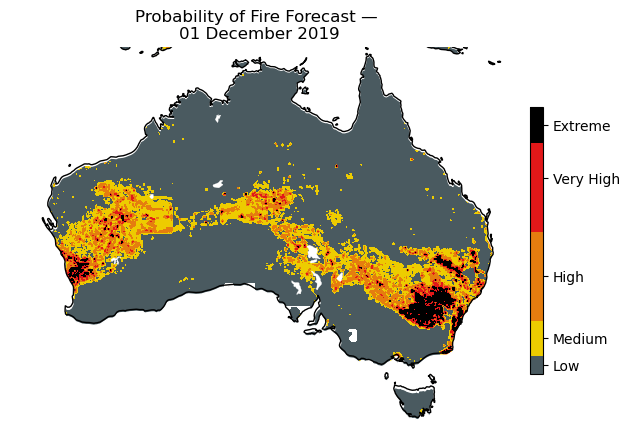

In [9]:
# Normally, Matplotlib makes simple x-y plots. But here we are plotting geographic data, so we need a map projection.

ax = plt.axes(projection=ccrs.PlateCarree())  #normal latitude-longitude coordinates

ax.coastlines(linewidth=1) #draws coastlines on the map.

# Draw a filled geographic probability map using longitude, latitude, and fire-probability values. (The input data are in normal longitude-latitude coordinates.)

fig = ax.contourf(sub_ds.longitude, sub_ds.latitude, fires,levels=levels,vmin=0,vmax=0.006,transform=ccrs.PlateCarree(),cmap=test)

ax.add_feature(cart.feature.OCEAN,zorder=1,edgecolor='k',color='white')                      # Add ocean color
ax.add_feature(cart.feature.BORDERS,linewidth=0.5,color='white')                             # Add country borders
ax.add_feature(cart.feature.LAKES,color='white', edgecolor='k', linewidth=0.2, zorder=2)     # Add lakes

#This creates a Natural Earth geographic feature for internal administrative boundaries.

states_provinces = cart.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        edgecolor='black'
)

#ax.add_feature(states_provinces, linewidth=0.5)


# Loop through all outer borders of the plot and hide them. This code removes those borders to make the map look cleaner and more professional.
for spine in ax.spines.values():
   spine.set_visible(False)

cbar = plt.colorbar(fig,ticks=[0.0002,0.0008,0.0022,0.0044,0.0056],fraction=0.025, pad=0.04)
cbar.ax.set_yticklabels(['Low', 'Medium','High', 'Very High', 'Extreme'])

#plt.title(plot_title, fontsize=16)
plt.title(f"Probability of Fire Forecast — \n01 December 2019")
plt.tight_layout()

plt.savefig('./outputs/My_PoF_Plot.png', dpi=300)

